---
title: Optimizadores
subject: Aprendizaje Profundo
subtitle: Comprendiendo las diferencias
short_title: Optimizadores
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

**Objetivo**: Comparar el comportamiento de distintos optimizadores mediante una actividad demostrativa.

En el curso hemos estudiado distintos optimizadores cuya función es actualizar los parámetros de la red neuronal durante el entrenamiento. Su elección resulta determinante para alcanzar un buen rendimiento en el menor número de iteraciones posible, especialmente en arquitecturas de gran profundidad.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Encontrando el mínimo valor de una función de una dimensión

A modo ilustrativo, aplicaremos los algoritmos de descenso de gradiente estándar y descenso de gradiente con momentum para localizar el mínimo de la función $x^2$. Es decir, partiendo desde un punto inicial buscaremos el valor mínimo de la parábola.

In [2]:
def f(x):
  """Funcion a optimizar"""
  return x**2

def grad(x):
  """Derivada de la función x**2"""
  return 2*x

In [3]:
def gd(x, grad, alpha, max_iter=10):
  """
  Implementación del algoritmo de gradiente descendente.
  Hiperparámetros:
  - alpha: learning rate
  - max_iter: número máximo de iteraciones
  """
  xs = np.zeros(1 + max_iter)
  xs[0] = x
  for i in range(max_iter):
    x = x - alpha*grad(x)    #x - learning rate * gradiente de x
    xs[i+1] = x

  return xs


def gd_momentum(x, grad, alpha, beta=0.9, max_iter=10):
  """Implementación del algoritmo de Gradiente con momentum"""
  xs = np.zeros(1 + max_iter)
  xs[0] = x

  v=0

  for i in range(max_iter):
    v = beta*v + (1-beta)*grad(x)
    vc = v/(1 + beta**(i+1)) #--> incluye bias correction
    x = x - alpha*vc
    xs[i+1] = x
  return xs

Primero aplicamos el descenso del gradiente con un learning rate moderado (0,1).

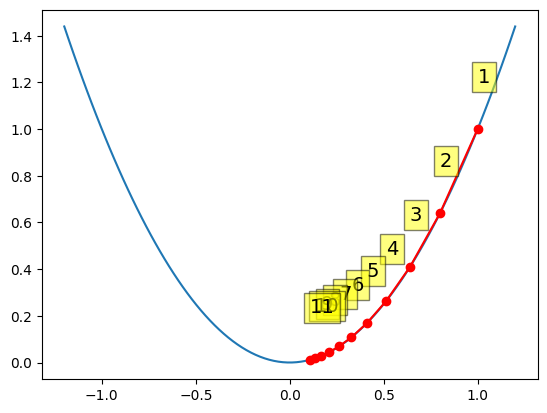

In [4]:

alpha = 0.1
x0 = 1
xs = gd(x0, grad, alpha)

xp = np.linspace(-1.2, 1.2, 100)
plt.plot(xp, f(xp))
plt.plot(xs, f(xs), 'o-', c='red')

for i, (x,y) in enumerate(zip(xs, f(xs)), 1):
  plt.text(x, y+0.2, i, bbox=dict(facecolor='yellow', alpha=0.5), fontsize=14)
pass

Ahora aplicamos el descenso del gradiente con un learning rate grande (0,95).

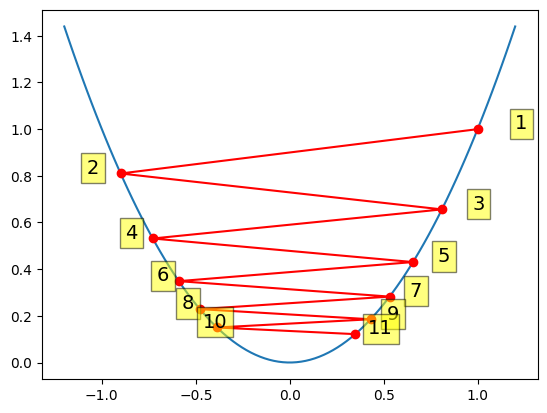

In [5]:
alpha = 0.95
x0 = 1
xs = gd(x0, grad, alpha)

xp = np.linspace(-1.2, 1.2, 100)
plt.plot(xp, f(xp))
plt.plot(xs, f(xs), 'o-', c='red')

for i, (x,y) in enumerate(zip(xs, f(xs)), 1):
  plt.text(x*1.2, y, i, bbox=dict(facecolor='yellow', alpha=0.5), fontsize=14)
pass

**<font color="teal">Pregunta 1</font>**  

<font color="teal">¿Qué conclusión puedes sacar?  </font>

Su respuesta aquí.

Ahora buscaremos el valor mínimo utilizando el algoritmo del descenso del gradiente con momentum.

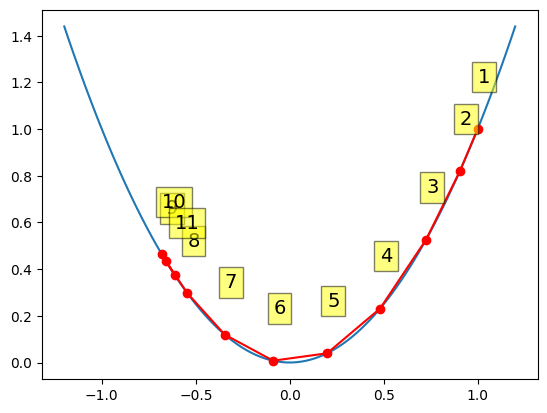

In [6]:
#Gradient descent with momentum
alpha = 0.9
x0 = 1
xs = gd_momentum(x0, grad, alpha, beta=0.9)

xp = np.linspace(-1.2, 1.2, 100)
plt.plot(xp, f(xp))
plt.plot(xs, f(xs), 'o-', c='red')

for i, (x,y) in enumerate(zip(xs, f(xs)), 1):
  plt.text(x, y+0.2, i, bbox=dict(facecolor='yellow', alpha=0.5), fontsize=14)
pass

Notar que en la iteración 6 el algoritmo sigue de largo, pero luego a partir de la iteración comienza a regresar.

## Buscando el mínimo de una función de dos dimensiones

Consideremos ahora la función $f(x,y) = x^2 + 100y^2$. Busquemos el valor mínimo probando diferentes optimizadores.


In [7]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

Definimos la función objetivo y gradiente

In [8]:
def f2(x):
  return x[0]**2 + 100*x[1]**2

def grad2(x):
  return np.array([2*x[0], 200*x[1]])


Definimos la grilla

In [9]:
x_range = np.linspace(-1.2, 1.2, 200)
y_range = np.linspace(-1.2, 1.2, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + 100 * Y**2

In [10]:
def gd2(x, grad, alpha, max_iter=10):
  """
  Implementación del algoritmo de gradiente descendente.
  Hiperparámetros:
  - alpha: learning rate
  - max_iter: número máximo de iteraciones
  """
  xs = np.zeros((1+max_iter,x.shape[0]))
  xs[0,:] = x

  for i in range(max_iter):
    x = x - alpha*grad(x)
    xs[i+1,:] = x
  return xs

In [11]:
def gd2_momentum(x, grad, alpha, beta=0.9, max_iter=10):
  """
  Implementación del algoritmo de gradiente descendente con momentum.
  Hiperparámetros:
  - alpha: learning rate
  - beta: momentum
  - max_iter: número máximo de iteraciones
  """
  xs = np.zeros((1+max_iter, x.shape[0]))
  xs[0,:] = x

  v = 0

  for i in range(max_iter):
    v = beta*v + (1-beta)*grad(x)
    vc = v/(1 + beta**(i+1))
    x = x - alpha*vc
    xs[i+1,:] = x
  return xs

In [12]:
def gd2_rmsprop(x, grad, alpha, beta=0.9, eps=1e-8, max_iter=10):
    """
    Implementación del algoritmo de RMSProp.
    Hiperparámetros:
    - alpha: learning rate
    - beta: momentum
    - eps: valor pequeño para evitar división por cero
    - max_iter: número máximo de iteraciones
    """
    xs = np.zeros((1 + max_iter, x.shape[0]))
    xs[0, :] = x
    v = 0
    for i in range(max_iter):
        v = beta * v + (1 - beta) * grad(x)**2
        x = x - alpha * grad(x) / (eps + np.sqrt(v))
        xs[i + 1, :] = x
    return xs


In [13]:
def gd2_adam(x, grad, alpha, beta1=0.9, beta2=0.999, eps=1e-8, max_iter=10):
    """
    Implementación del algoritmo de Adam.
    Hiperparámetros:
    - alpha: learning rate
    - beta1: momentum
    - beta2: momentum
    - eps: valor pequeño para evitar división por cero
    - max_iter: número máximo de iteraciones
    """
    xs = np.zeros((1 + max_iter, x.shape[0]))
    xs[0, :] = x
    m, v = 0, 0
    for i in range(max_iter):
        m = beta1 * m + (1 - beta1) * grad(x)
        v = beta2 * v + (1 - beta2) * grad(x)**2
        mc = m / (1 - beta1**(i + 1))
        vc = v / (1 - beta2**(i + 1))
        x = x - alpha * mc / (eps + np.sqrt(vc))
        xs[i + 1, :] = x
    return xs


In [16]:
#  Trayectorias
x0 = np.array([-1.0, 1.0])

trajectories = {
    "Vanilla GD":  gd2(x0, grad2, alpha=0.01, max_iter=75),
    "Momentum":    gd2_momentum(x0, grad2, alpha=0.01, beta=0.9, max_iter=75),
    "RMSProp":     gd2_rmsprop(x0, grad2, alpha=0.1, beta=0.9, max_iter=10),
    "Adam":        gd2_adam(x0, grad2, alpha=0.1, beta1=0.9, beta2=0.99, max_iter=10),
}

colors = {
    "Vanilla GD": "#FF4B4B",
    "Momentum":   "#00C8FF",
    "RMSProp":    "#FFD700",
    "Adam":       "#7CFF6B",
}

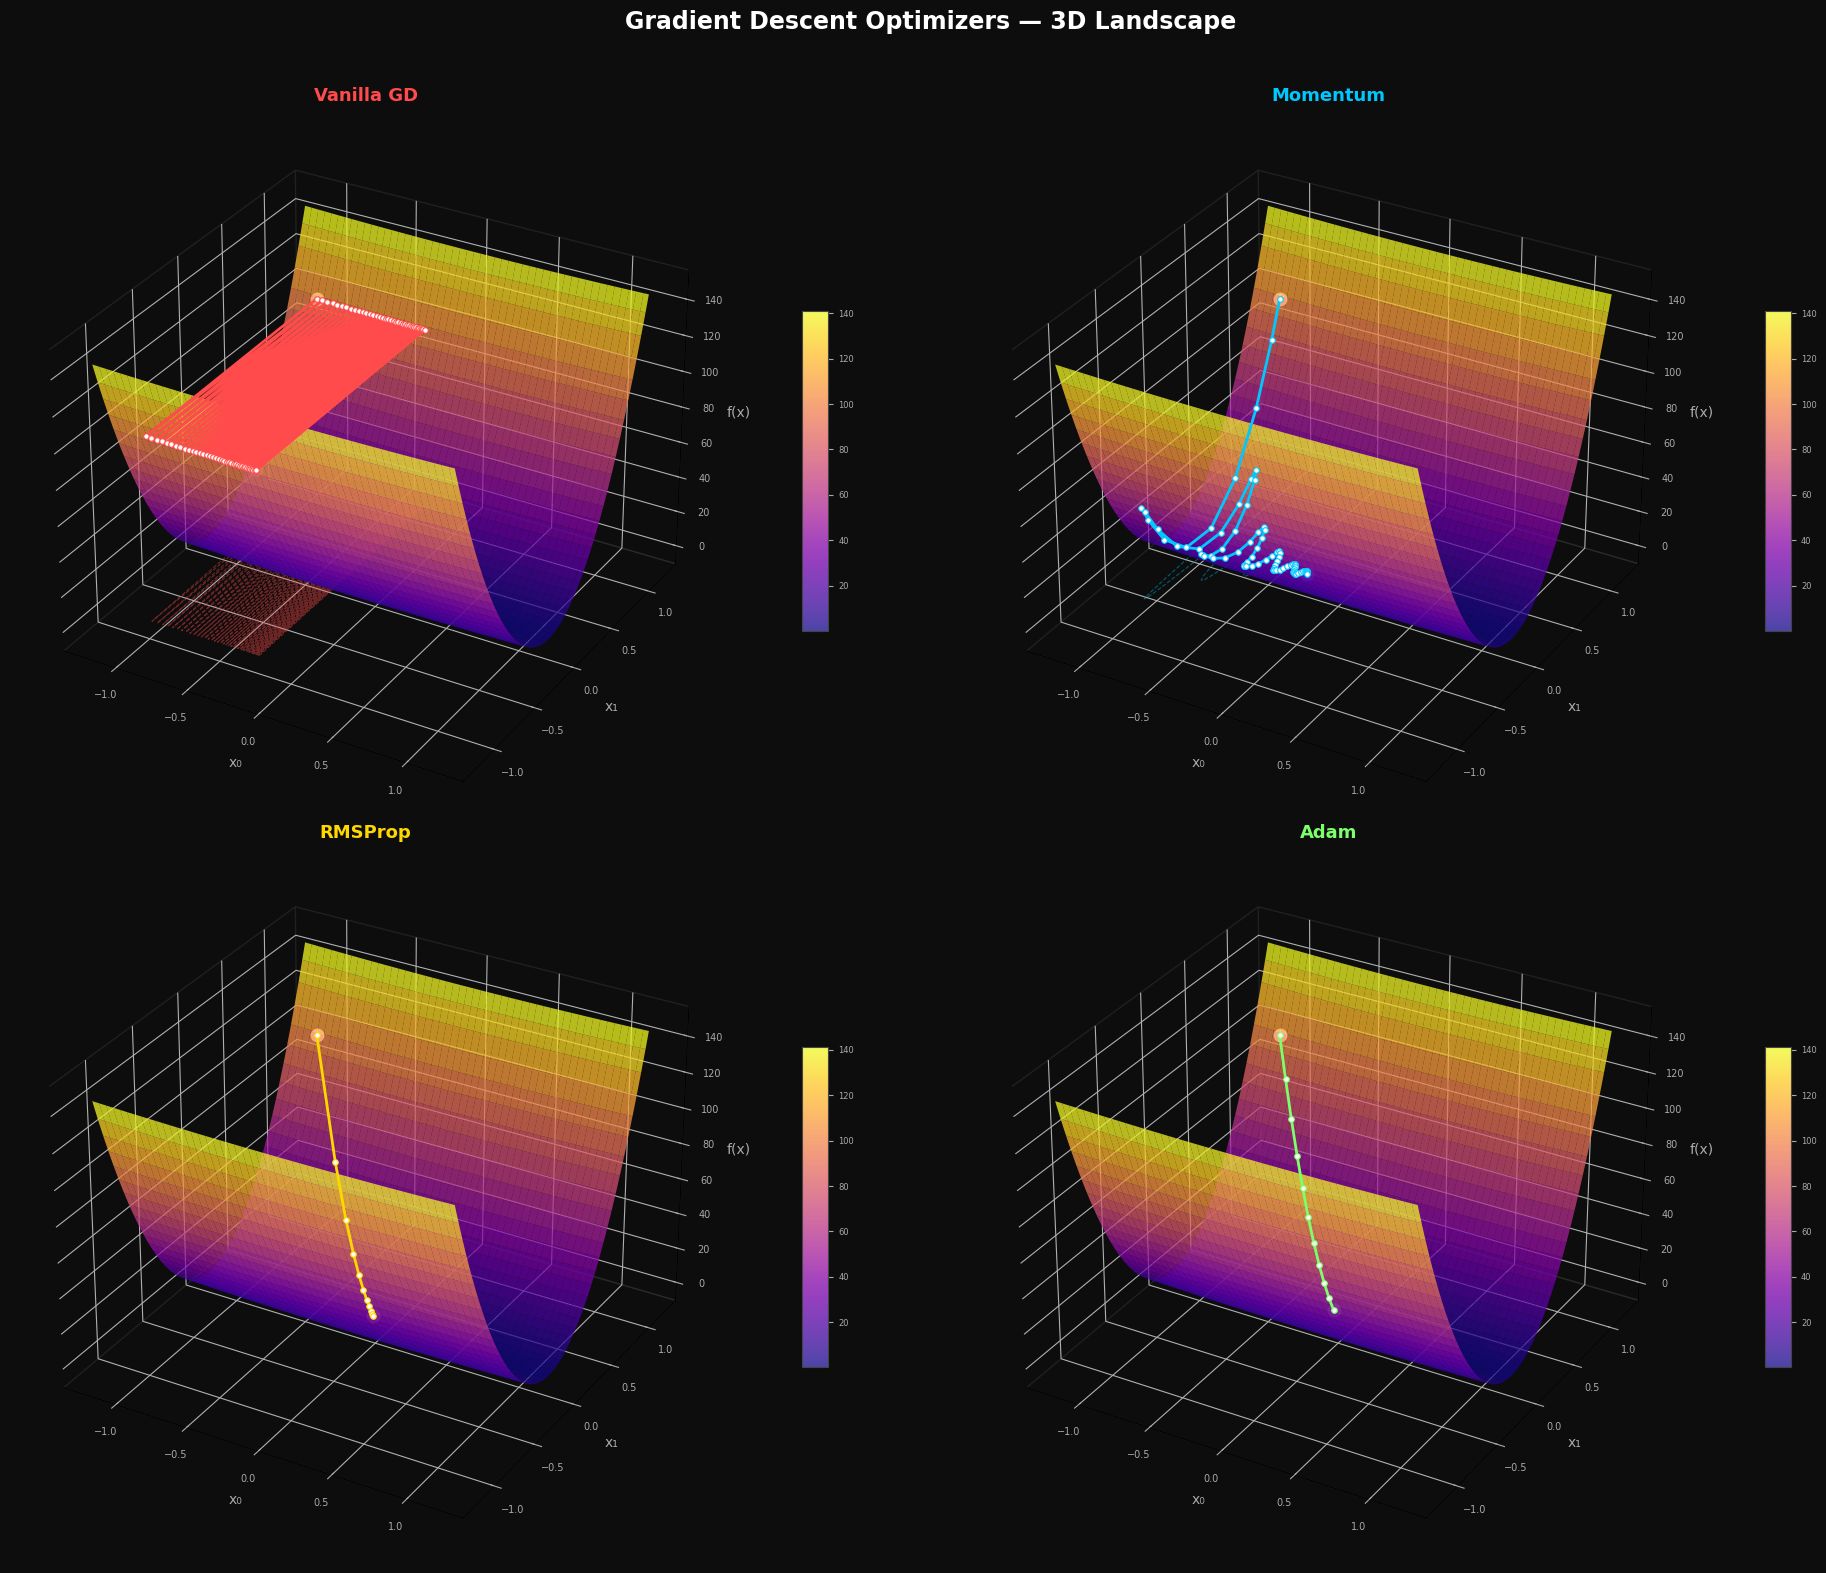

In [17]:
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor("#0D0D0D")

for idx, (name, xs) in enumerate(trajectories.items(), 1):
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    ax.set_facecolor("#0D0D0D")

    # Superficie semitransparente
    surf = ax.plot_surface(
        X, Y, Z,
        cmap=cm.plasma,
        alpha=0.75,
        linewidth=0,
        antialiased=True,
        zorder=0,
    )

    # Valores Z a lo largo de la trayectoria
    zs = np.array([f2(p) for p in xs])

    # Elevar ligeramente la trayectoria sobre la superficie para visibilidad
    offset = Z.max() * 0.02

    # Línea de trayectoria
    ax.plot(
        xs[:, 0], xs[:, 1], zs + offset,
        '-o',
        color=colors[name],
        linewidth=2.0,
        markersize=4,
        markerfacecolor='white',
        markeredgecolor=colors[name],
        markeredgewidth=0.8,
        zorder=10,
        label=name,
    )

    # Punto de inicio y fin
    ax.scatter(*xs[0], zs[0] + offset,  s=80, color='white',        zorder=15, depthshade=False)
    ax.scatter(*xs[-1], zs[-1] + offset, s=80, color=colors[name],  zorder=15, depthshade=False)

    # Proyección de la trayectoria en el plano Z=0 (sombra)
    ax.plot(
        xs[:, 0], xs[:, 1], np.zeros_like(zs),
        '--',
        color=colors[name],
        linewidth=0.8,
        alpha=0.4,
        zorder=1,
    )

    # Estilo de ejes
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False
        pane.set_edgecolor('#333333')

    ax.tick_params(colors='#AAAAAA', labelsize=7)
    ax.xaxis.label.set_color('#AAAAAA')
    ax.yaxis.label.set_color('#AAAAAA')
    ax.zaxis.label.set_color('#AAAAAA')
    ax.set_xlabel("x₀", labelpad=4)
    ax.set_ylabel("x₁", labelpad=4)
    ax.set_zlabel("f(x)", labelpad=4)
    ax.set_title(name, color=colors[name], fontsize=13, fontweight='bold', pad=10)

    ax.view_init(elev=30, azim=-60)

    # Colorbar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.45, aspect=12, pad=0.08)
    cbar.ax.tick_params(colors='#AAAAAA', labelsize=6)
    cbar.outline.set_edgecolor('#444444')

fig.suptitle(
    "Gradient Descent Optimizers — 3D Landscape",
    color='white', fontsize=17, fontweight='bold', y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

**<font color="teal">Pregunta 2</font>**  

<font color="teal">¿Qué optimizador pareciera que converge al valor mínimo en una menor cantidad de iteraciones?  </font>

Su respuesta aquí.